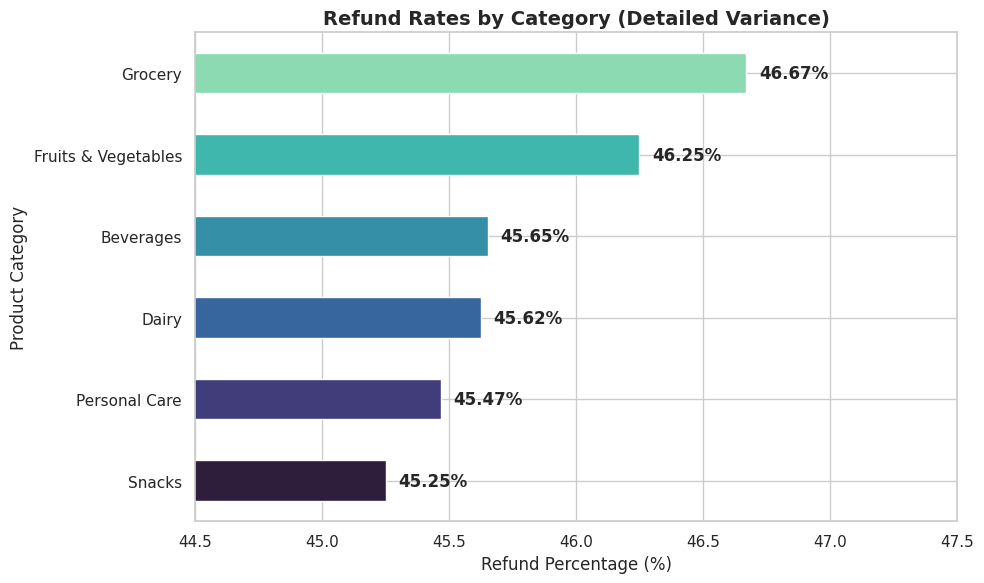

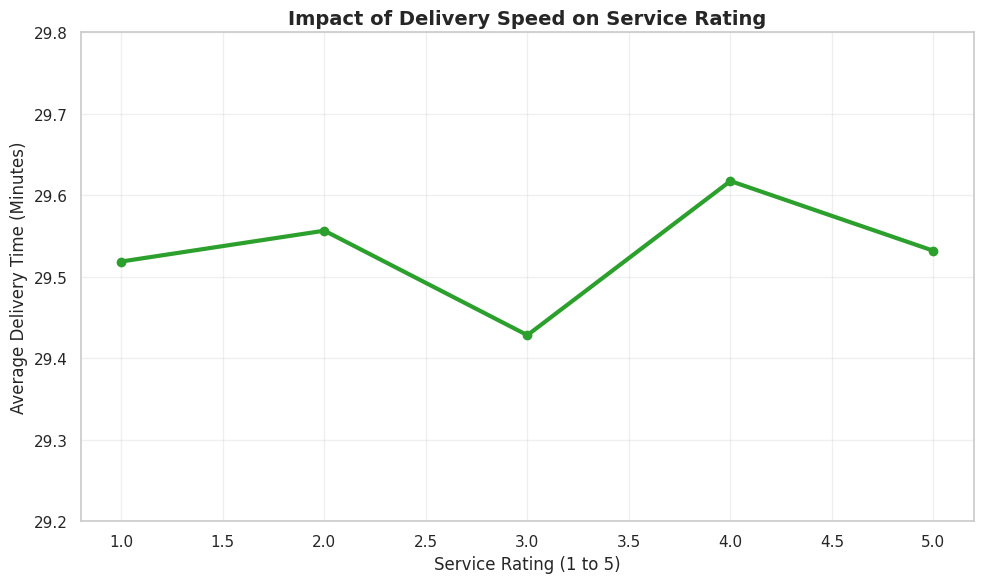

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the file
df = pd.read_csv('Ecommerce_Delivery_Analytics_New (1).csv')

# Set a clean, professional theme
sns.set_theme(style="whitegrid")

# --- CHART 1: REFUND RATES (Zoomed to show variance) ---
plt.figure(figsize=(10, 6))
refund_rates = df.groupby('Product Category')['Refund Requested'].apply(lambda x: (x == 'Yes').mean() * 100).sort_values()

# Use a professional color palette
colors = sns.color_palette("mako", len(refund_rates))
ax = refund_rates.plot(kind='barh', color=colors)

# KEY EDIT: Zoom into the 44%-47% range to make the bars look different
plt.xlim(44.5, 47.5)

plt.title('Refund Rates by Category (Detailed Variance)', fontsize=14, fontweight='bold')
plt.xlabel('Refund Percentage (%)')

# Add the exact values on the bars for the "Analyst" look
for i, v in enumerate(refund_rates):
    ax.text(v + 0.05, i, f'{v:.2f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('refund_analysis_zoomed.png', dpi=300)
plt.show()

# --- CHART 2: DELIVERY TREND (Line chart to show micro-changes) ---
plt.figure(figsize=(10, 6))
avg_delivery = df.groupby('Service Rating')['Delivery Time (Minutes)'].mean()

# A line chart shows the "trend" better than bars for this data
plt.plot(avg_delivery.index, avg_delivery.values, marker='o', color='#2ca02c', linewidth=3)

# KEY EDIT: Zoom into the 29-30 minute range
plt.ylim(29.2, 29.8)

plt.title('Impact of Delivery Speed on Service Rating', fontsize=14, fontweight='bold')
plt.xlabel('Service Rating (1 to 5)')
plt.ylabel('Average Delivery Time (Minutes)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('delivery_trend.png', dpi=300)
plt.show()


## Final Analysis & Recommendations
### 1. Summary

After performing Exploratory Data Analysis (EDA) on 100,000 delivery records, the primary finding is a high systemic refund rate (~46%) across all product categories and platforms.

### 2. Key Analytical Findings
* Perishable Quality Risk: "Grocery" and "Fruits & Vegetables" exhibit the highest refund rates (46.67% and 46.25% respectively). This indicates a critical need for enhanced quality-assurance checks at the packaging stage to reduce waste and customer dissatisfaction.

* Platform Benchmarking: There is negligible variance in service ratings between JioMart (3.25), Swiggy Instamart (3.24), and Blinkit (3.23). In such a competitive landscape, customer retention will likely depend on service reliability rather than just delivery speed.

* The Delivery-Rating Paradox: Ratings remain stable (approx. 3.2) whether the delivery takes 29.2 minutes or 29.8 minutes. This suggests that for quick-commerce customers in this segment, a 30-minute window is an acceptable threshold; improvements in speed below this mark may yield diminishing returns in customer satisfaction.

### 3. Proposed Practical Solutions

* Category-Specific QC: Implement a "freshness-first" automated check for the Grocery segment to target the 46.7% refund rate.

* Feedback Loop Integration: Analyze the "Customer Feedback" text column using sentiment analysis (Next Step) to identify the specific causes of the 1-star and 2-star ratings, as delivery time alone does not seem to be the primary driver.

* Operational Efficiency: Since minor delays do not heavily penalize ratings, the delivery fleet could be optimized for batch-delivery (multiple orders in one trip) to reduce costs without significantly damaging the brand's service rating.





